<a href="https://colab.research.google.com/github/Capaquira/projectsHighCode/blob/Notebooks/BoliviaGasProd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    explained_variance_score
)

import warnings
# Ignorar todos los warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

In [75]:
df = pd.read_excel('https://nube.ine.gob.bo/index.php/s/Zc56MHV1Zrt0fJY/download',header = None)
df.head()

,0,1,2,3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


Cleaning

In [76]:
'''Delete first rows'''
df_cleaned = df.iloc[6:,:]

'''Keep main columns'''
df_cleaned = df_cleaned[[1,2,3]]
df_cleaned.dropna(inplace=True)

'''Use first row as header'''
df_cleaned.columns = df_cleaned.iloc[0]
df_cleaned = df_cleaned[1:]

In [77]:
df_cleaned

6,PERIODO,PETRÓLEO(1),GAS NATURAL(2)
8,1990,7634931,2999.711891
9,Enero,593342,258.107632
10,Febrero,538733,227.95024
11,Marzo,585956,242.958144
12,Abril,590319,205.91977
...,...,...,...
506,Agosto,555435.89,897.456319
507,Septiembre,500469.82,815.107578
508,Octubre,540749.62,877.217899
509,Noviembre,527353.89,855.494061


In [78]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 468 entries, 8 to 510
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PERIODO         468 non-null    object
 1   PETRÓLEO(1)     468 non-null    object
 2   GAS NATURAL(2)  468 non-null    object
dtypes: object(3)
memory usage: 30.8+ KB


Consulta datos referentes a Gas

In [79]:
'''Query cumulative production by year'''
df_cleaned["PERIODO"] = df_cleaned["PERIODO"].astype(str)
df_cleaned["PERIODO"] = df_cleaned["PERIODO"].str.replace(r'\D', '', regex=True)
df_cleaned["PERIODO"].replace('', np.nan, inplace=True)
df_cleaned.dropna(subset=["PERIODO"], inplace=True)

In [80]:
df_cleaned

6,PERIODO,PETRÓLEO(1),GAS NATURAL(2)
8,1990,7634931,2999.711891
22,1991,8093520,2978.757459
36,1992,7751701,3046.576195
50,1993,8116478,3046.321344
64,1994,9381463,3279.481875
78,1995,10347316,3295.395917
92,1996,10682313,3329.291126
106,1997,11021345.63,3015.635787
120,1998,12628177.46,3105.602593
134,1999,10679990.84,2611.719855


In [81]:
'''Convert str values'''
df_cleaned['PERIODO'] = df_cleaned['PERIODO'].astype('int')
df_cleaned['PETRÓLEO(1)'] = df_cleaned['PETRÓLEO(1)'].astype('float').round(0)
df_cleaned['GAS NATURAL(2)'] = df_cleaned['GAS NATURAL(2)'].astype('float').round(0)

In [82]:
df_cleaned

6,PERIODO,PETRÓLEO(1),GAS NATURAL(2)
8,1990,7634931.0,3000.0
22,1991,8093520.0,2979.0
36,1992,7751701.0,3047.0
50,1993,8116478.0,3046.0
64,1994,9381463.0,3279.0
78,1995,10347316.0,3295.0
92,1996,10682313.0,3329.0
106,1997,11021346.0,3016.0
120,1998,12628177.0,3106.0
134,1999,10679991.0,2612.0


In [83]:
'''Rename Columns'''
df_cleaned['PETRÓLEO(1)'] = df_cleaned['PETRÓLEO(1)'].div(1000000).round(2)
df_cleaned['GAS NATURAL(2)'] = df_cleaned['GAS NATURAL(2)'].div(1000).round(2)
df_cleaned.rename(columns={"PERIODO": "YEAR"}, inplace=True)
df_cleaned.rename(columns={"PETRÓLEO(1)": "OIL"}, inplace=True)
df_cleaned.rename(columns={"GAS NATURAL(2)": "GAS"}, inplace=True)

In [84]:
df_cleaned

6,YEAR,OIL,GAS
8,1990,7.63,3.00
22,1991,8.09,2.98
36,1992,7.75,3.05
50,1993,8.12,3.05
64,1994,9.38,3.28
78,1995,10.35,3.30
92,1996,10.68,3.33
106,1997,11.02,3.02
120,1998,12.63,3.11
134,1999,10.68,2.61


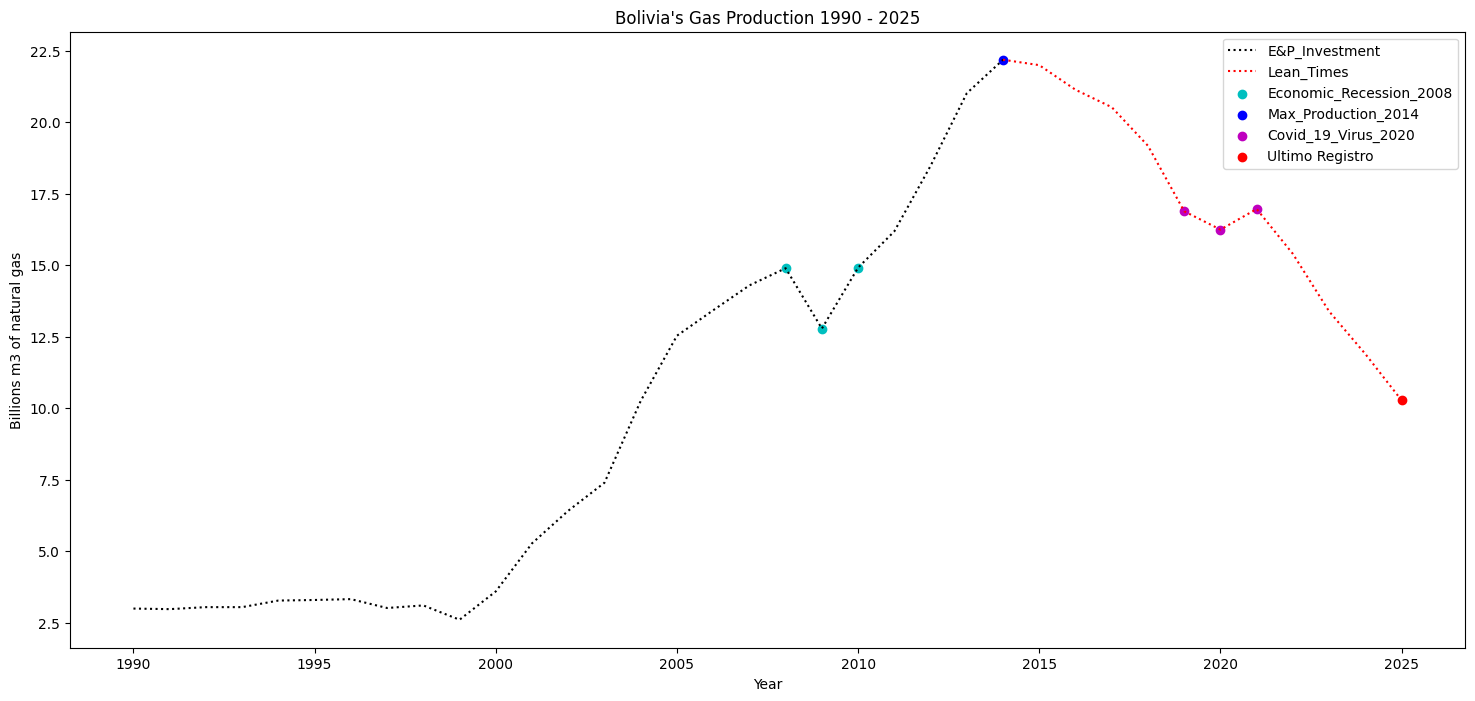

In [95]:
'''Plot data for Gas'''
years0 = range(1990,2015)
df_EP_Investment = df_cleaned.query("YEAR in @years0")

years1 = range(2014,2026)
df_lean_times = df_cleaned.query("YEAR in @years1")

years2 = range(2008,2011)
df_economic_recession_2008 = df_cleaned.query("YEAR in @years2")

years3 = 2014
df_max_production = df_cleaned.query("YEAR == 2014")

years4 = range(2019, 2022)
df_covid_19_virus = df_cleaned.query("YEAR in @years4")

years5 = 2025
df_ultimoRegistro = df_cleaned.query("YEAR == 2025")

x0 = df_EP_Investment.YEAR
y0 = df_EP_Investment.GAS
x1 = df_lean_times.YEAR
y1 = df_lean_times.GAS
x2 = df_economic_recession_2008.YEAR
y2 = df_economic_recession_2008.GAS
x3 = df_max_production.YEAR
y3 = df_max_production.GAS
x4 = df_covid_19_virus.YEAR
y4 = df_covid_19_virus.GAS
x5 = df_ultimoRegistro.YEAR
y5 = df_ultimoRegistro.GAS

plt.figure(figsize=(18,8))

plt.plot(x0, y0,color='k',linestyle = 'dotted',label='E&P_Investment')
plt.plot(x1, y1,color='r',linestyle = 'dotted',label='Lean_Times')
plt.scatter(x2, y2,color='c', label='Economic_Recession_2008')
plt.scatter(x3, y3,color='b', label='Max_Production_2014')
plt.scatter(x4, y4,color='m', label='Covid_19_Virus_2020')
plt.scatter(x5, y5,color='r', label='Ultimo Registro')

plt.title("Bolivia's Gas Production 1990 - 2025")
plt.ylabel("Billions m3 of natural gas")
plt.xlabel("Year")
plt.legend()
plt.show()

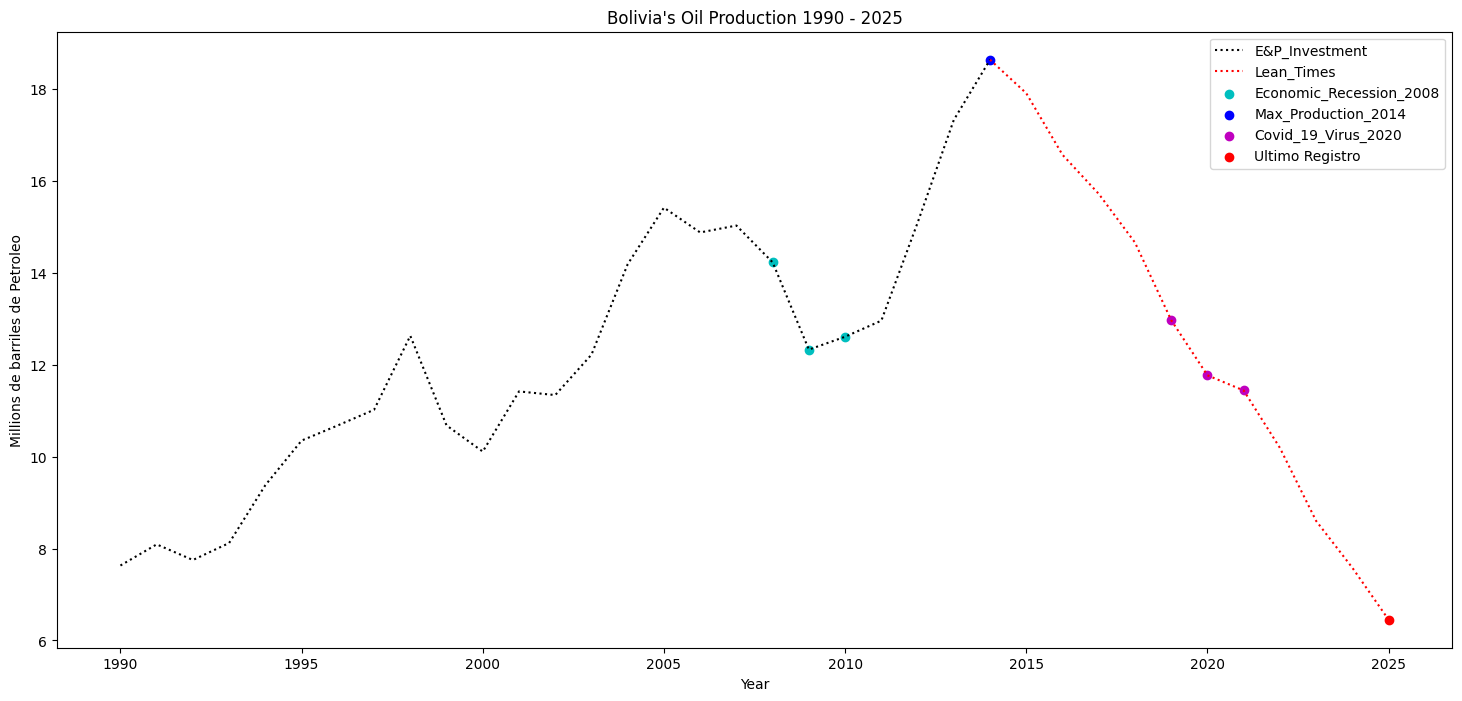

In [93]:
'''Plot data for Oil'''
years0 = range(1990,2015)
df_EP_Investment = df_cleaned.query("YEAR in @years0")

years1 = range(2014,2026)
df_lean_times = df_cleaned.query("YEAR in @years1")

years2 = range(2008,2011)
df_economic_recession_2008 = df_cleaned.query("YEAR in @years2")

years3 = 2014
df_max_production = df_cleaned.query("YEAR == 2014")

years4 = range(2019, 2022)
df_covid_19_virus = df_cleaned.query("YEAR in @years4")

years5 = 2025
df_ultimoRegistro = df_cleaned.query("YEAR == 2025")

x0 = df_EP_Investment.YEAR
y0 = df_EP_Investment.OIL

x1 = df_lean_times.YEAR
y1 = df_lean_times.OIL

x2 = df_economic_recession_2008.YEAR
y2 = df_economic_recession_2008.OIL

x3 = df_max_production.YEAR
y3 = df_max_production.OIL

x4 = df_covid_19_virus.YEAR
y4 = df_covid_19_virus.OIL

x5 = df_ultimoRegistro.YEAR
y5 = df_ultimoRegistro.OIL

plt.figure(figsize=(18,8))

plt.plot(x0, y0,color='k',linestyle = 'dotted',label='E&P_Investment')
plt.plot(x1, y1,color='r',linestyle = 'dotted',label='Lean_Times')
plt.scatter(x2, y2,color='c', label='Economic_Recession_2008')
plt.scatter(x3, y3,color='b', label='Max_Production_2014')
plt.scatter(x4, y4,color='m', label='Covid_19_Virus_2020')
plt.scatter(x5, y5,color='r', label='Ultimo Registro')

plt.title("Bolivia's Oil Production 1990 - 2025")
plt.ylabel("Millions de barriles de Petroleo")
plt.xlabel("Year")
plt.legend()
plt.show()